### Handling Multiple Schemas

#### Intermediate State

Intermediate state is useful for storing intermediate data needed for the internal workings of the graph, but not required for the overall graph input or output.

    In this setup, we'll define both an OverallState and a IntermediateState.
    
    Node 2 takes IntermediateState as its input but writes its results to OverallState.

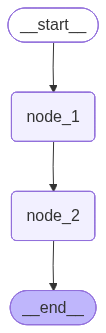

In [17]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# ---- Define OverallState and IntermediateState ----

class OverallState(TypedDict):
    task_progress: int  # Overall progress (in percentage)

class IntermediateState(TypedDict):
    temp_progress: int  # Temporary progress used during calculations

# ---- Node 1: Calculates intermediate progress ----

def node_1(state: OverallState) -> IntermediateState:
    print("---Node 1: Calculating intermediate progress---")
    # Add 10% progress based on the current overall progress
    return {"temp_progress": state['task_progress'] + 10}

# ---- Node 2: Updates overall progress ----

def node_2(state: IntermediateState) -> OverallState:
    print("---Node 2: Updating overall progress---")
    # Use intermediate data to update overall progress
    return {"task_progress": state['temp_progress']}

# ---- Build Graph ----

builder = StateGraph(OverallState)  # Define the overall state for the graph

# Add nodes to the graph
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Define the graph's logic (edges between nodes)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Compile the graph
graph = builder.compile()

# ---- View the Graph ----
display(Image(graph.get_graph().draw_mermaid_png()))




In [18]:
# ---- Run the Graph with Initial Data ----
result = graph.invoke({"task_progress": 40})  # Starting progress is 40%
print(f"Final Task Progress: {result['task_progress']}%")

---Node 1: Calculating intermediate progress---
---Node 2: Updating overall progress---
Final Task Progress: 50%


## Input and Output Schema

By default, StateGraph uses a single schema that all nodes interact with. However, it's possible to define separate input and output schemas for the graph. In such cases, an "internal" schema is typically used to manage all the keys relevant to the graph’s operations. Specific input and output schemas are then applied to constrain the data flowing into and out of the nodes.

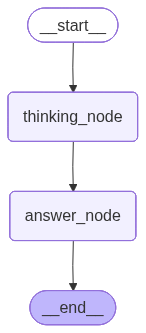

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# ---- State Types ----

class InputState(TypedDict):
    query: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    setup: str
    punchline: str
    notes: str


# ---- Nodes ----

def thinking_node(state: InputState) -> dict:
    """Generate the joke setup and punchline."""
    q = state.get("query", "")
    print(q)

    # Simple logic to pick a joke based on the query
    if "chicken" in q.lower():
        setup = "Why did the chicken cross the road?"
        punchline = "To get to the other side!"
    else:
        setup = "Why don't programmers like nature?"
        punchline = "Too many bugs."

    return {
        "setup": setup,
        "punchline": punchline,
        "notes": "Generated a joke based on the user's query."
    }


def answer_node(state: OverallState) -> OutputState:
    """Produce the final formatted response."""
    return {
        "answer": f"{state['setup']}\n{state['punchline']}"
    }


# ---- Build Graph ----

graph = StateGraph(OverallState,input_schema=InputState,output_schema=OutputState)

graph.add_node("thinking_node", thinking_node)
graph.add_node("answer_node", answer_node)

graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# ---- View the graph ----
display(Image(graph.get_graph().draw_mermaid_png()))



In [6]:
# ---- Run it ----
graph.invoke({"query": "Tell me a joke on chicken "})


Tell me a joke on chicken 


{'answer': 'Why did the chicken cross the road?\nTo get to the other side!'}

In [7]:
# ---- Run it ----
graph.invoke({"query": "Tell me a joke on programmers "})

Tell me a joke on programmers 


{'answer': "Why don't programmers like nature?\nToo many bugs."}

## Example 2

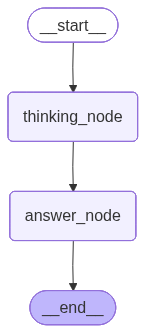

{'answer': 'bye Lance'}

In [3]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "bye", "notes": "... his is name is Lance"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question":"hi"})